# 04 - Regression

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# === CONFIG ===
INPUT_CSV = 'AB_NYC_2019_cleaned.csv'
METRICS_CSV = 'regression_metrics.csv'
COEF_CSV = 'regression_coefficients.csv'
FIGURES_DIR = 'figures'

FEATURES = [
    'room_type_code', 'neighbourhood_group_code',
    'latitude', 'longitude', 'minimum_nights',
    'number_of_reviews', 'reviews_per_month',
    'availability_365', 'calculated_host_listings_count'
]
TARGET = 'log_price'

# 80/20 split
TEST_SIZE = 0.2
RANDOM_STATE = 1

# Polynomial degree
POLY_DEGREE = 2

# VIF threshold (diagnostic)
VIF_THRESHOLD = 5.0

DPI = 300
COLOR_PRIMARY = 'steelblue'
COLOR_SECONDARY = 'darkorange'
# === END CONFIG ===

os.makedirs(FIGURES_DIR, exist_ok=True)

In [3]:
def log_table(title, df, decimals=None, index=True):
    print()
    print('--- ' + title + ' ---')
    if decimals is not None:
        print(df.round(decimals).to_string(index=index))
    else:
        print(df.to_string(index=index))

In [4]:
df = pd.read_csv(INPUT_CSV)
X = df[FEATURES]
y = df[TARGET]
print(f'Rows: {len(df)}')
print(f'Features: {FEATURES}')
print(f'Target: {TARGET}')

Rows: 48847
Features: ['room_type_code', 'neighbourhood_group_code', 'latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365', 'calculated_host_listings_count']
Target: log_price


In [5]:
# VIF diagnostic
vif_rows = []
for col in X.columns:
    y_i = X[col]
    X_i = X.drop(columns=[col])
    reg_i = LinearRegression()
    reg_i.fit(X_i, y_i)
    r2 = reg_i.score(X_i, y_i)
    if r2 >= 1.0:
        vif_value = float('inf')
    else:
        vif_value = 1.0 / (1.0 - r2)
    vif_rows.append({'feature': col, 'VIF': vif_value})
vif_initial = pd.DataFrame(vif_rows)
log_table('VIF diagnostic', vif_initial, decimals=3, index=False)
print(f'VIF threshold = {VIF_THRESHOLD}; no pruning.')

# Keep all features (no automated VIF pruning)
X_model = X


--- VIF diagnostic ---
                       feature   VIF
                room_type_code 1.061
      neighbourhood_group_code 1.607
                      latitude 1.195
                     longitude 1.494
                minimum_nights 1.241
             number_of_reviews 1.561
             reviews_per_month 1.625
              availability_365 1.191
calculated_host_listings_count 1.154
VIF threshold = 5.0; no pruning.


/.../site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/.../site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/.../site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/.../site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/.../site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/.../site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/.../site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/.../s

In [6]:
# Train / test split
X_train, X_test, y_train, y_test = train_test_split(X_model, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)
print(f'Train/test split: {1.0 - TEST_SIZE:.2f} / {TEST_SIZE:.2f}, random_state = {RANDOM_STATE}')

# StandardScaler on training only
scaler = StandardScaler()
X_train_scaled_arr = scaler.fit_transform(X_train)
X_test_scaled_arr = scaler.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_scaled_arr, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled_arr, columns=X_test.columns, index=X_test.index)

Train/test split: 0.80 / 0.20, random_state = 1


In [7]:
# Baseline: room_type_code only (business question)
baseline_feature = 'room_type_code'

# Feature correlation with target (context)
correlations_raw = X_train.corrwith(y_train)
correlations = correlations_raw.abs().sort_values(ascending=False)
log_table('Feature absolute correlation with target (training set)', correlations, decimals=3)


--- Feature absolute correlation with target (training set) ---
room_type_code                    0.613
neighbourhood_group_code          0.342
longitude                         0.329
calculated_host_listings_count    0.132
availability_365                  0.096
latitude                          0.080
reviews_per_month                 0.058
minimum_nights                    0.049
number_of_reviews                 0.042


In [8]:
# Model 1: linear baseline
lin_single = LinearRegression()
lin_single.fit(X_train_scaled[[baseline_feature]], y_train)
y_pred_single = lin_single.predict(X_test_scaled[[baseline_feature]])

# Model 2: multiple linear
lin_multi = LinearRegression()
lin_multi.fit(X_train_scaled, y_train)
y_pred_multi = lin_multi.predict(X_test_scaled)

# Model 3: polynomial degree 2
poly = PolynomialFeatures(degree=POLY_DEGREE, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)
lin_poly = LinearRegression()
lin_poly.fit(X_train_poly, y_train)
y_pred_poly = lin_poly.predict(X_test_poly)

/.../site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/.../site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/.../site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/.../site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/.../site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/.../site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


In [9]:
# Metrics per model
r2_single = r2_score(y_test, y_pred_single); mae_single = mean_absolute_error(y_test, y_pred_single)
mse_single = mean_squared_error(y_test, y_pred_single); rmse_single = float(np.sqrt(mse_single))
r2_multi = r2_score(y_test, y_pred_multi); mae_multi = mean_absolute_error(y_test, y_pred_multi)
mse_multi = mean_squared_error(y_test, y_pred_multi); rmse_multi = float(np.sqrt(mse_multi))
r2_poly = r2_score(y_test, y_pred_poly); mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly); rmse_poly = float(np.sqrt(mse_poly))

metrics_df = pd.DataFrame({
    'model': ['Linear (room type only)', 'Multiple linear (scaled)', 'Polynomial degree ' + str(POLY_DEGREE) + ' (scaled)'],
    'R2': [r2_single, r2_multi, r2_poly],
    'MAE': [mae_single, mae_multi, mae_poly],
    'MSE': [mse_single, mse_multi, mse_poly],
    'RMSE': [rmse_single, rmse_multi, rmse_poly]
})
metrics_df.to_csv(METRICS_CSV, index=False)
log_table('Model metrics (test set)', metrics_df, decimals=4, index=False)


--- Model metrics (test set) ---
                       model     R2    MAE    MSE   RMSE
     Linear (room type only) 0.3720 0.4025 0.2998 0.5475
    Multiple linear (scaled) 0.4803 0.3598 0.2481 0.4981
Polynomial degree 2 (scaled) 0.5343 0.3383 0.2223 0.4714


In [10]:
# Coefficients (multiple linear) sorted by |coefficient|
coef_df = pd.DataFrame({'feature': X_model.columns, 'coefficient': lin_multi.coef_})
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coefficient', ascending=False).drop(columns=['abs_coefficient'])
coef_df.to_csv(COEF_CSV, index=False)
log_table('Multiple linear coefficients on scaled features (sorted by |coefficient|)', coef_df, decimals=4, index=False)
print(f'Intercept (multi): {lin_multi.intercept_:.4f}')

# Residuals summary
residuals = y_test - y_pred_multi
log_table('Residuals summary', residuals.describe(), decimals=4)


--- Multiple linear coefficients on scaled features (sorted by |coefficient|) ---
                       feature  coefficient
                room_type_code      -0.3971
      neighbourhood_group_code      -0.1249
              availability_365       0.1222
                     longitude      -0.1075
                minimum_nights      -0.0879
             number_of_reviews      -0.0376
                      latitude       0.0339
             reviews_per_month      -0.0183
calculated_host_listings_count       0.0164
Intercept (multi): 4.7374

--- Residuals summary ---
count    9770.0000
mean       -0.0096
std         0.4980
min        -2.9745
25%        -0.3167
50%        -0.0624
75%         0.2298
max         4.4010


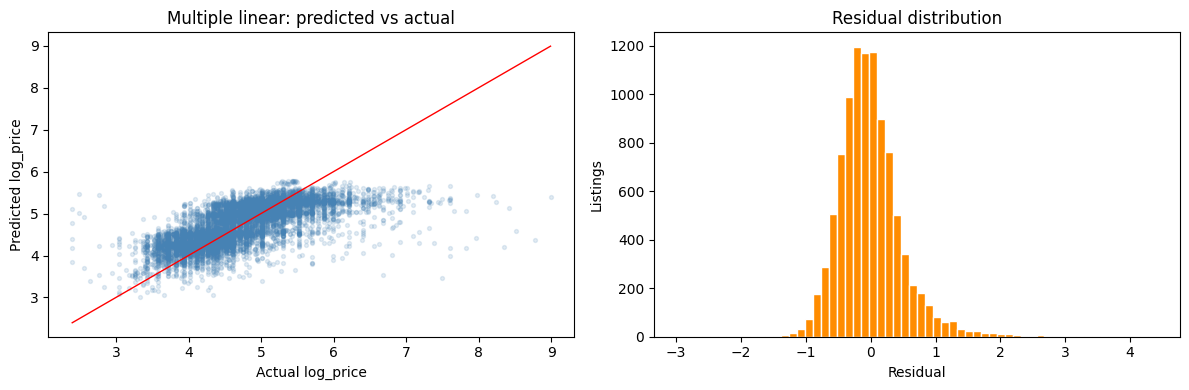

In [11]:
# Figure: predicted vs actual + residuals (multiple linear)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(y_test, y_pred_multi, alpha=0.15, s=8, color=COLOR_PRIMARY)
lo = y_test.min(); hi = y_test.max()
ax[0].plot([lo, hi], [lo, hi], color='red', linewidth=1)
ax[0].set_xlabel('Actual log_price'); ax[0].set_ylabel('Predicted log_price')
ax[0].set_title('Multiple linear: predicted vs actual')
ax[1].hist(residuals, bins=60, color=COLOR_SECONDARY, edgecolor='white')
ax[1].set_xlabel('Residual'); ax[1].set_ylabel('Listings')
ax[1].set_title('Residual distribution')
plt.tight_layout()
plt.savefig(FIGURES_DIR + '/fig_regression_evidence.png', dpi=DPI)
plt.show()